

#📦 **Dependencies and Library Imports**

**Purpose:**
This cell imports all required libraries for data handling, model building, training, evaluation, and visualization.

**What this cell establishes:**

*   Core scientific stack: NumPy, Pandas

*   Deep learning framework: PyTorch

*   Dataset handling: KaggleHub

*   Evaluation utilities: scikit-learn

**Visualization tools**

This ensures the notebook is self-contained and reproducible.

In [ ]:
import time, random, numpy as np, pandas as pd, torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import kagglehub
from kagglehub import KaggleDatasetAdapter ## handel datasets from kaggle



🔹 **Cell 2: Random Seed Definition and Device Setup**

🎯 **Reproducibility and Hardware Configuration**

**Purpose:**
To ensure reproducible results and detect available hardware (CPU or GPU).

**Key ideas demonstrated:**

* Fixing randomness across NumPy, Python, and PyTorch

* Enforcing deterministic behavior in CUDA

* Dynamically selecting CPU/GPU

* Explicitly moving models and tensors to the chosen device


In [ ]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

# --- Seed & device ---
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.use_deterministic_algorithms(True)

set_seed()


## here we set the device which is an important step to check on GPU/CPU which is available and after theat move the model into device (discussed below)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


#🔹 **Data Loading and Preprocessing (Rain Prediction)**

🌦️ **Dataset Loading and Feature Engineering**

**Purpose:**
To prepare a real-world binary classification dataset (RainTomorrow) for neural network training.

**What happens here:**

* Dataset is loaded from Kaggle using kagglehub

* Relevant numerical and categorical features are selected

* Binary categorical variables are encoded

* Missing values are removed

* Train–test split with stratification

* Feature scaling applied only on training data

* Conversion to PyTorch tensors

* Construction of DataLoaders

**Key concept introduced:**

Neural networks are sensitive to feature scale — normalization is essential.

In [ ]:
file_path = "weatherAUS.csv"
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "jsphyg/weather-dataset-rattle-package", file_path)

# Alternatively you can use
#df = pd.read_csv("File Path")

**Feature Representation**

In [ ]:
# this are the features from the dataset we want to feed into the model and raintomorrow is the target
cols = ['Rainfall', 'Humidity3pm', 'Pressure9am', 'RainToday', 'RainTomorrow']
df = df[cols].copy()

## we are converting categorical strings to numeric binary
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})



# we remove any rows with NaN values in any of the selected columns
df = df.dropna(subset=cols).reset_index(drop=True)



num_feats = ['Rainfall', 'Humidity3pm', 'Pressure9am']  ## these are the numerical features
cat_feats = ['RainToday']  # already 0/1 which are categorical in nature



# we are converting into float32 datatype because pytorch ddefault tensor datatype is float32
X_num = df[num_feats].values.astype(np.float32)
X_cat = df[cat_feats].values.astype(np.float32)

y = df['RainTomorrow'].values.astype(np.float32)

X_num_tr, X_num_te, X_cat_tr, X_cat_te, y_tr, y_te = train_test_split( X_num, X_cat, y, test_size=0.2, random_state=42, stratify=y)  # the stratify function is for preserving class distribution


scaler = StandardScaler()

X_num_tr = scaler.fit_transform(X_num_tr) # the fit we use here learrns column-wise mean and std from train set.
X_num_te = scaler.transform(X_num_te)


X_tr = np.concatenate([X_num_tr, X_cat_tr], axis=1)
X_te = np.concatenate([X_num_te, X_cat_te], axis=1)


# converting float32 to tensor
Xt = torch.tensor(X_tr, dtype=torch.float32)
Xv = torch.tensor(X_te, dtype=torch.float32)


yt = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1) # a second dimension to match the output shape of a binary classifier head
yv = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)



train_loader = DataLoader(TensorDataset(Xt, yt), batch_size=256, shuffle=True)
test_loader  = DataLoader(TensorDataset(Xv, yv), batch_size=1024, shuffle=False)


/tmp/ipython-input-2097902085.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "jsphyg/weather-dataset-rattle-package", file_path)


Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.


In [ ]:
df.shape

(124689, 5)

In [ ]:
display(df[cols].head(10))

,Rainfall,Humidity3pm,Pressure9am,RainToday,RainTomorrow
0,0.6,22.0,1007.7,0.0,0.0
1,0.0,25.0,1010.6,0.0,0.0
2,0.0,30.0,1007.6,0.0,0.0
3,0.0,16.0,1017.6,0.0,0.0
4,1.0,33.0,1010.8,0.0,0.0
5,0.2,23.0,1009.2,0.0,0.0
6,0.0,19.0,1009.6,0.0,0.0
7,0.0,19.0,1013.4,0.0,0.0
8,0.0,9.0,1008.9,0.0,1.0
9,1.4,27.0,1007.0,1.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124689 entries, 0 to 124688
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Rainfall      124689 non-null  float64
 1   Humidity3pm   124689 non-null  float64
 2   Pressure9am   124689 non-null  float64
 3   RainToday     124689 non-null  float64
 4   RainTomorrow  124689 non-null  float64
dtypes: float64(5)
memory usage: 4.8 MB


#**Defining of Neural Network**

🔹 **Baseline Neural Network**


🧠 **Deep Neural Network Without Batch Normalization**

**Purpose:**
To establish a baseline deep neural network and observe its training behavior.

**Architecture characteristics:**

* Fully connected feedforward network

* Deep architecture with progressively shrinking layers

* ReLU activations

* Binary classification using logits

* BCEWithLogitsLoss for numerical stability

**Learning focus:**

* Depth alone does not guarantee stability

* Training dynamics without normalization

* Loss convergence and runtime behavior

In [ ]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

### this is the  part where we will be creating a Neural Network model

# --- Model (no BN) ---

class NetNoBN(nn.Module):
    def __init__(self, n_features):  # constructor where we are passing the input features (4)
        super().__init__()
        self.fc1 = nn.Linear(n_features, 128)
        self.fc2 = nn.Linear(128, 48)
        self.fc3 = nn.Linear(48, 40)
        self.fc4 = nn.Linear(40, 32)
        self.fc5 = nn.Linear(32, 24)
        self.fc6 = nn.Linear(24, 8)
        self.fc7 = nn.Linear(8, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x=  F.relu(self.fc6(x))
        return self.fc7(x)  # logits

# initialising the model and sending to the device which we specified above
model = NetNoBN(n_features=4).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()


[NoBN] --> Epoch 01 | Loss: 0.4083 | Time: 5.45s
[NoBN] --> Epoch 02 | Loss: 0.3787 | Time: 4.67s
[NoBN] --> Epoch 03 | Loss: 0.3781 | Time: 2.72s
[NoBN] --> Epoch 04 | Loss: 0.3781 | Time: 2.28s
[NoBN] --> Epoch 05 | Loss: 0.3775 | Time: 2.46s
[NoBN] --> Epoch 06 | Loss: 0.3777 | Time: 3.02s
[NoBN] --> Epoch 07 | Loss: 0.3771 | Time: 2.28s
[NoBN] --> Epoch 08 | Loss: 0.3775 | Time: 2.28s
[NoBN] --> Epoch 09 | Loss: 0.3773 | Time: 2.26s
[NoBN] --> Epoch 10 | Loss: 0.3775 | Time: 2.45s
[NoBN] --> Epoch 11 | Loss: 0.3770 | Time: 3.01s
[NoBN] --> Epoch 12 | Loss: 0.3772 | Time: 2.25s
[NoBN] --> Epoch 13 | Loss: 0.3768 | Time: 2.25s
[NoBN] --> Epoch 14 | Loss: 0.3769 | Time: 2.21s
[NoBN] --> Epoch 15 | Loss: 0.3767 | Time: 2.24s
[NoBN] --> Epoch 16 | Loss: 0.3767 | Time: 3.20s
[NoBN] --> Epoch 17 | Loss: 0.3765 | Time: 2.25s
[NoBN] --> Epoch 18 | Loss: 0.3765 | Time: 2.21s
[NoBN] --> Epoch 19 | Loss: 0.3763 | Time: 2.22s
[NoBN] --> Epoch 20 | Loss: 0.3764 | Time: 2.23s
[NoBN] --> Epoch 21 

#🔹 **Training Loop (No BatchNorm)**

🔁 **Model Training Loop (Baseline Network)**

**Purpose:**
To demonstrate a standard supervised training loop in PyTorch.

**Concepts reinforced:**

* Forward pass → loss → backward pass → optimizer step

* Epoch-wise loss tracking

* GPU synchronization for accurate timing

Importance of model.train() vs model.eval()

This cell shows **what training actually looks** like, not a black box.

In [ ]:
####---###---Training starts here---###----#####

epochs = 25
train_losses = []


total_start = time.time()

for epoch in range(1, epochs+1):
    model.train()
    running = 0
    if torch.cuda.is_available(): torch.cuda.synchronize()
    epoch_start = time.time()

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)


        # make previous gradients zero
        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        # gradient step
        optimizer.step()

        running += loss.item()

    if torch.cuda.is_available(): torch.cuda.synchronize()
    epoch_time = time.time() - epoch_start

    epoch_loss = running/len(train_loader)

    train_losses.append(epoch_loss)
    print(f"[NoBN] --> Epoch {epoch:02d} | Loss: {epoch_loss:.4f} | Time: {epoch_time:.2f}s")

if torch.cuda.is_available(): torch.cuda.synchronize()
total_time = time.time() - total_start
print(f"[NoBN]--> Total Training Time: {total_time:.2f}s")


🔹 **Cell 6: Model Evaluation**

📊 **Evaluation on Test Data**

**Purpose:**
To evaluate classification performance on unseen data.

**Key ideas demonstrated:**

* Turning logits into probabilities using sigmoid

* Thresholding probabilities for binary classification

* Accuracy as an evaluation metric

* Separation of training and evaluation logic

In [ ]:
# --- Evaluation (accuracy) ---
model.eval()
all_logits, all_targets = [], []

# we no need to track gradient
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        z = model(xb).cpu().numpy().ravel()
        all_logits.append(z)
        all_targets.append(yb.numpy().ravel())
logits = np.concatenate(all_logits)
probs  = 1/(1+np.exp(-logits))
ytrue  = np.concatenate(all_targets)
ypred  = (probs >= 0.5).astype(np.int32)
acc    = accuracy_score(ytrue, ypred)
print(f"Final Test Accuracy: {acc*100:.2f}% | Last Train Loss: {train_losses[-1]:.4f}")

#🔹 **Neural Network Visualization**

🖼️ **Visualizing Neural Network Architecture**

**Purpose:**
To provide an intuitive structural view of the neural network.

**What this helps students understand:**

* Layer-wise flow of information

* Relative depth and width

* Input–hidden–output organization

* Why “deep” really means many transformations

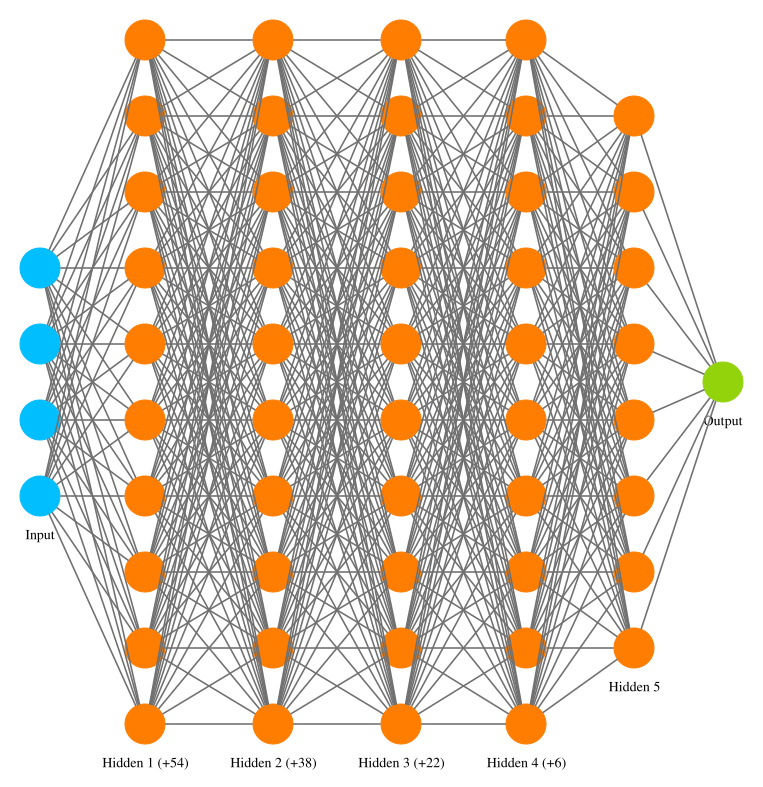

In [ ]:
from graphviz import Digraph
import torch.nn as nn

def ann_viz_torch(model: nn.Module, filename="Net_block", view=True, max_nodes=10):
    layers = [m for m in model.modules() if isinstance(m, nn.Linear)]
    in_dim = layers[0].in_features
    hidden_dims = [l.out_features for l in layers[:-1]]
    out_dim = layers[-1].out_features

    def cap(n): s=min(n,max_nodes); return s, n-s
    in_s,in_e = cap(in_dim)
    hid_s_e = [cap(h) for h in hidden_dims]
    out_s,out_e = cap(out_dim)

    g = Digraph("ANN", filename=filename, format="png")
    g.graph_attr.update(rankdir="LR", nodesep="0.5", ranksep="0.6", splines="false")
    g.edge_attr.update(arrowhead="none", color="#707070", penwidth="1.6")
    nid=0
    def add_layer(label, count, color="#01BEFE"):
        nonlocal nid
        ids=[]
        with g.subgraph(name=f"cluster_{label}") as c:
            c.attr(color="white", label=label, labelloc="b")
            c.node_attr.update(shape="circle", style="filled", width="0.55", color=color, fontcolor=color)
            for _ in range(count):
                nid+=1; ids.append(str(nid)); c.node(ids[-1])
        return ids

    lab=f"Input{f' (+{in_e})' if in_e>0 else ''}"
    prev = add_layer(lab, in_s, "#01BEFE")
    for i,(s,e) in enumerate(hid_s_e,1):
        lab=f"Hidden {i}{f' (+{e})' if e>0 else ''}"
        cur = add_layer(lab, s, "#FF7D00")
        for u in prev:
            for v in cur: g.edge(u,v)
        prev=cur
    lab=f"Output{f' (+{out_e})' if out_e>0 else ''}"
    out = add_layer(lab, out_s, "#93D30C")
    for u in prev:
        for v in out: g.edge(u,v)

    if view: g.view()
    return g

# usage:
ann_viz_torch(model, filename="Net_block", view=True, max_nodes=10)


#🔹 **Neural Network With Batch Normalization**

⚖️ **Effect of Batch Normalization**

**Purpose:**
To compare training behavior **with and without Batch Normalization.**

**Key ideas introduced:**

* Internal covariate shift

* Stabilized gradients

* Faster and smoother convergence

* Regularization effect via noise

**Design choices:**

* BatchNorm after each linear layer

* Weight decay added to optimizer

In [ ]:
##############----################# With BatchNorm #############-------####################

class NetBN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 64);
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 48);
        self.bn2 = nn.BatchNorm1d(48)
        self.fc3 = nn.Linear(48, 32);
        self.bn3 = nn.BatchNorm1d(32)
        self.fc4 = nn.Linear(32, 16);
        self.bn4 = nn.BatchNorm1d(16)
        self.fc5 = nn.Linear(16, 8);
        self.bn5 = nn.BatchNorm1d(8)
        self.fc6 = nn.Linear(8, 1)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = F.relu(self.bn4(self.fc4(x)))
        x = F.relu(self.bn5(self.fc5(x)))
        return self.fc6(x)  # logits

model = NetBN(n_features=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()


epochs = 25
train_losses = []


total_start = time.time()

for epoch in range(1, epochs+1):
    model.train()
    running, count = 0.0, 0
    if torch.cuda.is_available(): torch.cuda.synchronize()
    epoch_start = time.time()

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)


        # make previous
        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        # gradient step
        optimizer.step()

        running += loss.item()

    if torch.cuda.is_available(): torch.cuda.synchronize()
    epoch_time = time.time() - epoch_start
    epoch_loss = running/len(train_loader)
    train_losses.append(epoch_loss)
    print(f"[BN] --> Epoch {epoch:02d} | Loss: {epoch_loss:.4f} | Time: {epoch_time:.2f}s")

if torch.cuda.is_available(): torch.cuda.synchronize()
total_time = time.time() - total_start
print(f"[BN]--> Total Training Time: {total_time:.2f}s")




# --- Evaluation (accuracy) ---
model.eval()
all_logits, all_targets = [], []

# we no need to track gradient
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        z = model(xb).cpu().numpy().ravel()
        all_logits.append(z)
        all_targets.append(yb.numpy().ravel())


logits = np.concatenate(all_logits)
probs  = 1/(1+np.exp(-logits))
ytrue  = np.concatenate(all_targets)
ypred  = (probs >= 0.5).astype(np.int32)  # that is if >=0.5 then it will rain tomorrow and else no rain
acc    = accuracy_score(ytrue, ypred) ## inbuilt from scikit learn library ( correct predictions/ total )
print(f"Final Test Accuracy: {acc*100:.2f}% | Last Train Loss: {train_losses[-1]:.4f}")

RuntimeError: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility

#🔹 **Activation Function Experiments**

🔥 **Exploring Different Activation Functions**

**Purpose:**
To study how activation functions influence learning dynamics.

**Activations tested:**

* ReLU

* SELU

* GELU

* Leaky ReLU

* ELU

**Key takeaway:**

Activation functions shape how information flows and gradients propagate.

In [ ]:
class Net(nn.Module):
    def __init__(self, n_features, activations=None):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(n_features, 64)
        self.fc2 = nn.Linear(64, 48)
        self.fc3 = nn.Linear(48, 32)
        self.fc4 = nn.Linear(32, 16)
        self.fc5 = nn.Linear(16, 8)
        self.fc6 = nn.Linear(8, 1)


        if activations is None:
            activations = ["relu"] * 5
        self.activations = activations


    def act(self, x, act_type):
        if act_type == "relu":
            return F.relu(x)
        elif act_type == "leaky_relu":
            return F.leaky_relu(x, negative_slope=0.01)
        elif act_type == "elu":
            return F.elu(x, alpha=1.0)
        elif act_type == "gelu":
            return F.gelu(x)
        elif act_type == "selu":
            return F.selu(x)
        else:
            return x  # identity

    def forward(self, x):
        x = self.act(self.fc1(x), self.activations[0])
        x = self.act(self.fc2(x), self.activations[1])
        x = self.act(self.fc3(x), self.activations[2])
        x = self.act(self.fc4(x), self.activations[3])
        x = self.act(self.fc5(x), self.activations[4])
        x = self.fc6(x)
        return torch.sigmoid(x)





#model = Net(n_features=4).to(device)

model = Net(n_features=4, activations=["relu", "selu", "relu", "gelu", "selu"]).to(device)

#### ----##### Optimizer & loss (BCELoss since model returns probabilities) ###----###
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

In [ ]:
epochs = 25
train_losses = []

for epoch in range(1, epochs+1):
    model.train()
    running = 0.0
    count = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        probs = model(xb)                 # already sigmoid
        loss = criterion(probs, yb)
        loss.backward()
        optimizer.step()

        running += loss.item() * xb.size(0)
        count += xb.size(0)

    epoch_loss = running / count
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch:02d} | Train Loss: {epoch_loss:.4f}")

# ---- Evaluate on test ----
model.eval()
all_probs, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        probs = model(xb).cpu().numpy().ravel()
        all_probs.append(probs)
        all_targets.append(yb.numpy().ravel())

probs = np.concatenate(all_probs)
ytrue = np.concatenate(all_targets)
ypred = (probs >= 0.5).astype(np.int32)

test_acc = accuracy_score(ytrue, ypred)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# Also show the last training loss:
print(f"Last Epoch Train Loss: {train_losses[-1]:.4f}")


# 🔹 **Optimizer Comparison**

⚙️ **Effect of Different Optimizers**

**Purpose:**
To observe how optimization algorithms affect convergence speed and stability.

**Optimizers included:**

* Adam

* SGD

* SGD + Momentum

* AdamW

* RMSprop

**Key insight:**

Architecture may stay the same, but optimizer choice changes training behavior dramatically.

In [ ]:

class Net(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 64)
        self.fc2 = nn.Linear(64, 48)
        self.fc3 = nn.Linear(48, 32)
        self.fc4 = nn.Linear(32, 16)
        self.fc5 = nn.Linear(16, 8)
        self.fc6 = nn.Linear(8, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = self.fc6(x)
        return torch.sigmoid(x)  # keeping sigmoid as requested


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net(n_features=4).to(device)

criterion = nn.BCELoss()  # since we're returning sigmoid probabilities





optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# optimizer = torch.optim.SGD(model.parameters(), lr=5e-2, momentum=0.9)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
# optimizer = torch.optim.RMSprop(model.parameters(), lr=1e-3) ( often used in RNNs )

In [ ]:
epochs = 25
train_losses = []


total_start = time.time()

for epoch in range(1, epochs+1):
    model.train()
    running, count = 0.0, 0
    if torch.cuda.is_available(): torch.cuda.synchronize()
    epoch_start = time.time()

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)


        # make previous
        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        # gradient step
        optimizer.step()

        running += loss.item()

    if torch.cuda.is_available(): torch.cuda.synchronize()
    epoch_time = time.time() - epoch_start
    epoch_loss = running/len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch:02d} | Loss: {epoch_loss:.4f} | Time: {epoch_time:.2f}s")

if torch.cuda.is_available(): torch.cuda.synchronize()
total_time = time.time() - total_start
print(f"Total Training Time: {total_time:.2f}s")


# ---- Evaluate on test ----
model.eval()
all_probs, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        probs = model(xb).cpu().numpy().ravel()
        all_probs.append(probs)
        all_targets.append(yb.numpy().ravel())

probs = np.concatenate(all_probs)
ytrue = np.concatenate(all_targets)
ypred = (probs >= 0.5).astype(np.int32)

test_acc = accuracy_score(ytrue, ypred)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# Also show the last training loss:
print(f"Last Epoch Train Loss: {train_losses[-1]:.4f}")


#🔹 **Dropout Regularization**

🧯 **Dropout for Regularization**

**Purpose:**
To demonstrate overfitting mitigation using Dropout.

**Concepts illustrated:**

* Random neuron deactivation during training

* Implicit ensemble behavior

* Trade-off between regularization and convergence speed


In [ ]:
class DropNN(nn.Module):
  def __init__(self, features, dropout_p):
    super().__init__()
    self.fc1 = nn.Linear(features, 24)
    self.fc2 = nn.Linear(24,38)
    self.drop = nn.Dropout(dropout_p)
    self.fc3 = nn.Linear(38,64)
    self.drop = nn.Dropout(dropout_p)
    self.fc4 = nn.Linear(64,38)
    self.drop = nn.Dropout(dropout_p)
    self.fc5 = nn.Linear(38,24)
    self.drop = nn.Dropout(dropout_p)
    self.fc6 = nn.Linear(24,1)

  def forward(self,x):
    x = self.fc1(x)
    x = F.relu(x)
    x = self.drop(x)
    x = self.fc2(x)
    x = F.relu(x)
    x = self.drop(x)
    x = self.fc3(x)
    x = F.relu(x)
    x = self.drop(x)
    x = self.fc4(x)
    x = F.relu(x)
    x = self.drop(x)
    x = self.fc5(x)
    x = F.relu(x)
    x = self.drop(x)
    x = self.fc6(x)
    return torch.sigmoid(x)



model = DropNN(features=4, dropout_p = 0.3).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()



In [ ]:
epochs = 25
train_losses = []


total_start = time.time()

for epoch in range(1, epochs+1):
    model.train()
    running, count = 0.0, 0
    if torch.cuda.is_available(): torch.cuda.synchronize()
    epoch_start = time.time()

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)


        # make previous
        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        # gradient step
        optimizer.step()

        running += loss.item()

    if torch.cuda.is_available(): torch.cuda.synchronize()
    epoch_time = time.time() - epoch_start
    epoch_loss = running/len(train_loader)
    train_losses.append(epoch_loss)
    print(f"[ Epoch {epoch:02d} | Loss: {epoch_loss:.4f} | Time: {epoch_time:.2f}s")

if torch.cuda.is_available(): torch.cuda.synchronize()
total_time = time.time() - total_start
print(f"Total Training Time: {total_time:.2f}s")


# ---- Evaluate on test ----
model.eval()
all_probs, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        probs = model(xb).cpu().numpy().ravel()
        all_probs.append(probs)
        all_targets.append(yb.numpy().ravel())

probs = np.concatenate(all_probs)
ytrue = np.concatenate(all_targets)
ypred = (probs >= 0.5).astype(np.int32)

test_acc = accuracy_score(ytrue, ypred)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# Also show the last training loss:
print(f"Last Epoch Train Loss: {train_losses[-1]:.4f}")


#🔹 **Prediction on New Data**

🔮 **Inference on New Samples**

**Purpose:**
To show how a trained neural network is used for real-world prediction.

**Pipeline demonstrated:**

* Feature scaling using trained scaler

* Feature concatenation

* Tensor conversion

* Probability output and thresholding

* Human-readable interpretation

In [ ]:
#  Example: predict if it will rain tomorrow for given datapoints
# Format: [Rainfall, Humidity3pm, Pressure9am], RainToday (0/1)

# New samples
X_new_num = np.array([
    [2.4, 85.0, 1012.3],   # sample 1
    [0.0, 28.0, 1004.0],   # sample 2
], dtype=np.float32)

X_new_rtoday = np.array([
    [1.0],   # RainToday = Yes
    [0.0],   # RainToday = No
], dtype=np.float32)

# 1) scale numeric features are updated during training
X_new_num = scaler.transform(X_new_num)

# 2) concatenate with RainToday column
X_new = np.concatenate([X_new_num, X_new_rtoday], axis=1)

# 3) convert to tensor and predict
model.eval()
with torch.no_grad():
    xb = torch.tensor(X_new, dtype=torch.float32).to(device)
    probs = model(xb).cpu().numpy().ravel()
    preds = (probs >= 0.5).astype(int)

# Show results
for i, (p, pr) in enumerate(zip(preds, probs)):
    print(f"Sample {i}: P(RainTomorrow=1)={pr:.3f} → Predicted: {'Rain' if p==1 else 'No Rain'}")


#🔹 **Multiclass Classification (Iris Dataset)**

🌸 **Extending Neural Networks to Multiclass Problems**

**Purpose:**
To generalize neural networks beyond binary classification.

**New concepts introduced:**

* Multiclass targets

* CrossEntropyLoss

* Softmax implicitly handled by loss

*bargmax for prediction

**Pedagogical strength:**
Shows **same network idea**, different loss → different task.

Another example : for multiclass classification

The IRIS dataset : --->
3 classes of flowers  150 samples

Setosa

Versicolor

Virginica

Each flower is described by 4 numerical features:

Sepal length (cm)

Sepal width (cm)

Petal length (cm)

Petal width (cm)

The target (y) is the flower species (0, 1, or 2).

In [ ]:
from sklearn.datasets import load_iris

############## --------############### data (Iris, 3 classes)################### -----------######################
X, y = load_iris(return_X_y=True)
X = X.astype(np.float32)
y = y.astype(np.int64) # required for cross entropy loss


print(X.shape)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler() # standardise fucntion(each column)


X_tr = scaler.fit_transform(X_tr) # learns from train set
X_te = scaler.transform(X_te)

Xt = torch.tensor(X_tr, dtype=torch.float32)
Xv = torch.tensor(X_te, dtype=torch.float32)
yt = torch.tensor(y_tr, dtype=torch.long)
yv = torch.tensor(y_te, dtype=torch.long)

train_loader = DataLoader(TensorDataset(Xt, yt), batch_size=16, shuffle=True)
test_loader  = DataLoader(TensorDataset(Xv, yv), batch_size=64, shuffle=False)

# --- model ---
class Net(nn.Module):
    def __init__(self, n_features, n_classes, activations=None):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(n_features, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, n_classes)
        if activations is None:
            activations = ["relu", "relu"]
        self.activations = activations

    def act(self, x, act_type):
        if act_type == "relu": return F.relu(x)
        elif act_type == "tanh": return torch.tanh(x)
        elif act_type == "gelu": return F.gelu(x)
        elif act_type == "selu": return F.selu(x)
        elif act_type == "leaky_relu": return F.leaky_relu(x, 0.01)
        else: return x

    def forward(self, x):
        x = self.act(self.fc1(x), self.activations[0])
        x = self.act(self.fc2(x), self.activations[1])
        return self.fc3(x)   # logits

model = Net(n_features=4, n_classes=3, activations=["relu","tanh"]).to(device)

# --- training setup ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- train ---
epochs = 30
for ep in range(1, epochs+1):
    model.train()
    total, n = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0); n += xb.size(0)
    print(f"Epoch {ep:02d} | Train Loss: {total/n:.4f}")

# --- test accuracy ---
model.eval()
all_preds, all_targs = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb.to(device)).argmax(dim=1).cpu().numpy()
        all_preds.append(pred)
        all_targs.append(yb.numpy())
all_preds = np.concatenate(all_preds)
all_targs = np.concatenate(all_targs)
acc = accuracy_score(all_targs, all_preds)
print(f"Test Accuracy: {acc*100:.2f}%")
